<a href="https://colab.research.google.com/github/manesanika115/_ml2/blob/main/Ml2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv("/content/housing.csv", sep=r'\s+', header=None)
data.columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
data.shape

(506, 14)

In [ ]:
data.isnull()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,False,False,False,False,False,False,False,False,False,False,False,False,False,False
502,False,False,False,False,False,False,False,False,False,False,False,False,False,False
503,False,False,False,False,False,False,False,False,False,False,False,False,False,False
504,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
data.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
501,False
502,False
503,False
504,False


In [ ]:
data.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [ ]:
data.empty

False

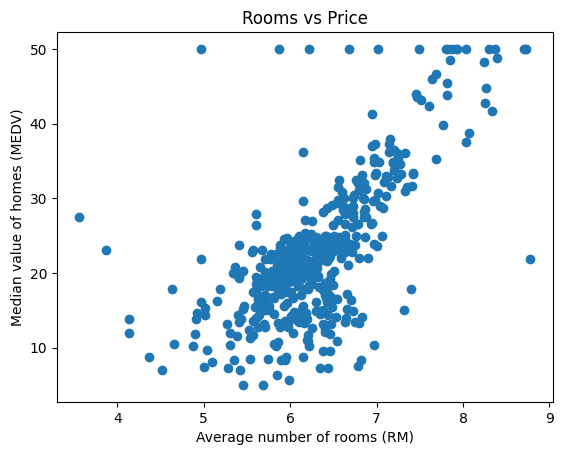

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(data["RM"], data["MEDV"])

plt.xlabel("Average number of rooms (RM)")
plt.ylabel("Median value of homes (MEDV)")
plt.title("Rooms vs Price")
plt.show()

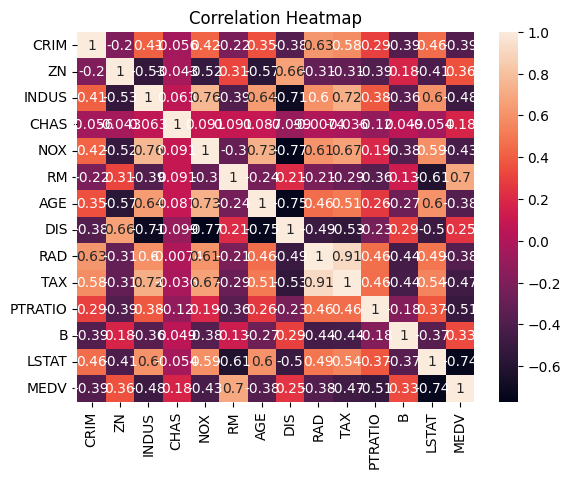

In [ ]:
corelation = data.corr(numeric_only=True)

sns.heatmap(corelation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

#input features
X = data.drop("MEDV",axis=1)

#target variable
y = data["MEDV"]

#Split dataset into tranining and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")

Training data: (404, 13)
Testing data: (102, 13)


In [ ]:
print("Training data:")
print(X_train.head())

Training data:
         CRIM    ZN  INDUS  CHAS     NOX     RM   AGE     DIS  RAD    TAX  \
477  15.02340   0.0  18.10     0  0.6140  5.304  97.3  2.1007   24  666.0   
15    0.62739   0.0   8.14     0  0.5380  5.834  56.5  4.4986    4  307.0   
332   0.03466  35.0   6.06     0  0.4379  6.031  23.3  6.6407    1  304.0   
423   7.05042   0.0  18.10     0  0.6140  6.103  85.1  2.0218   24  666.0   
19    0.72580   0.0   8.14     0  0.5380  5.727  69.5  3.7965    4  307.0   

     PTRATIO       B  LSTAT  
477     20.2  349.48  24.91  
15      21.0  395.62   8.47  
332     16.9  362.25   7.83  
423     20.2    2.52  23.29  
19      21.0  390.95  11.28  


In [ ]:
print("Testing data:")
print(X_test.head())

Testing data:
        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
173  0.09178   0.0   4.05     0  0.510  6.416  84.1  2.6463    5  296.0   
274  0.05644  40.0   6.41     1  0.447  6.758  32.9  4.0776    4  254.0   
491  0.10574   0.0  27.74     0  0.609  5.983  98.8  1.8681    4  711.0   
72   0.09164   0.0  10.81     0  0.413  6.065   7.8  5.2873    4  305.0   
452  5.09017   0.0  18.10     0  0.713  6.297  91.8  2.3682   24  666.0   

     PTRATIO       B  LSTAT  
173     16.6  395.50   9.04  
274     17.6  396.90   3.53  
491     20.1  390.11  18.07  
72      19.2  390.91   5.52  
452     20.2  385.09  17.27  


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
model.predict(X_test)

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992,
       23.25442929, 17.66253818, 14.34119   , 23.01320703, 20.63245597,
       24.90850512, 18.63883645, -6.08842184, 21.75834668, 19.23922576,
       26.19319733, 20.64773313,  5.79472718, 40.50033966, 17.61289074,
       27.24909479, 30.06625441, 11.34179277, 24.16077616, 17.86058499,
       15.83609765, 22.78148106, 14.57704449, 22.43626052, 19.19631835,
       22.43383455, 25.21979081, 25.93909562, 17.70162434, 16.76911711,
       16.95125411, 31.23340153, 20.13246729, 23.76579011, 24.6322925 ,
       13.94204955, 32.25576301, 42.67251161, 17.32745046, 27.27618614,
       16.99310991, 14.07009109, 25.90341861, 20.29485982, 29.95339638,
       21.28860173, 34.34451856, 16.04739105, 26.22562412, 39.53939798,
       22.57950697, 18.84531367, 32.72531661, 25.0673037 , 12.88628956,
       22.68221908, 30.48287757, 31.52626806, 15.90148607, 20.22094826,
       16.71089812, 20.52384893, 25.96356264, 30.61607978, 11.59

In [ ]:
Y_Pred = model.predict(X_test)

In [ ]:
print("Prediction values:",Y_Pred[0:3])

Prediction values: [28.99672362 36.02556534 14.81694405]


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, Y_Pred)
r2 = r2_score(y_test, Y_Pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)
#

Mean Squared Error: 24.291119474973478
R-squared: 0.6687594935356326
